[Previous: Architecture 2: Layered, Hexagonal and MVC](02_Layered_Hexagonal_and_MVC.ipynb)  |  [Course Index](../00_Start_Here.ipynb)  |  [Next: Architecture 4: Event-Driven and CQRS](04_Event_Driven_and_CQRS.ipynb)

# Architecture 3: Microservices

**Learning objectives.** After this module you can:

* describe what a microservice owns and what independence it buys;
* do the availability arithmetic for a chain of services and see it in a simulation;
* implement the three basic resilience tools: timeouts, retries and a circuit breaker;
* recognise the distributed monolith and say why it is the worst of both worlds.

## 1. What a microservice is

A service is a separately deployed process that **owns its data** and exposes an API. Other services talk to it over the network, never to its database.
Each team can deploy, scale and rewrite its service without asking the others. That is the promise, and for large organisations it is a real one.

Everything that follows is the bill. The shop below is split into three services; the network is simulated so that every call has latency and can fail.

order placed in 45 ms of network time


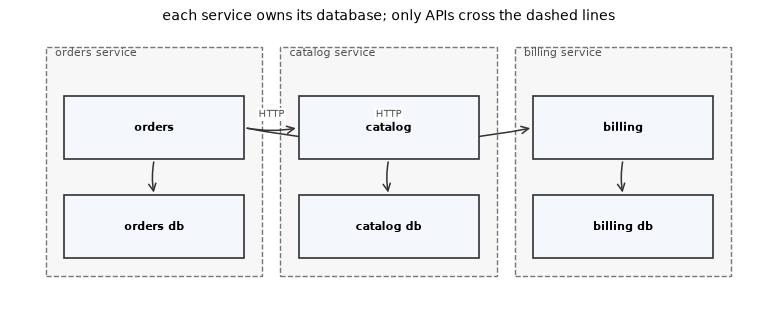

In [1]:
import random, time, math
from dplab import component_diagram, simulate_requests, traced, trace

class Network:
    # A pretend network: every call costs some milliseconds and fails with some probability.
    def __init__(self, mean_ms=20, fail_rate=0.02, seed=1):
        self.mean_ms, self.fail_rate, self.rng = mean_ms, fail_rate, random.Random(seed)
        self.calls = 0
    def call(self, service, method, *args):
        self.calls += 1
        latency = self.rng.lognormvariate(math.log(self.mean_ms), 0.5)
        if self.rng.random() < self.fail_rate:
            raise ConnectionError(f"{type(service).__name__}.{method} timed out after {latency:.0f} ms")
        return getattr(service, method)(*args), latency

@traced
class CatalogService:
    def __init__(self): self.db = {"lamp": 25.0, "chair": 80.0}          # its own data
    def price(self, item): return self.db[item]

@traced
class BillingService:
    def __init__(self): self.db = []
    def charge(self, customer, amount): self.db.append((customer, amount)); return "ok"

@traced
class OrderService:
    def __init__(self, net, catalog, billing): self.net, self.catalog, self.billing = net, catalog, billing
    def place(self, customer, item):
        price, l1 = self.net.call(self.catalog, "price", item)
        _ok, l2 = self.net.call(self.billing, "charge", customer, price * 1.2)
        return f"order placed in {l1 + l2:.0f} ms of network time"

net = Network()
orders = OrderService(net, CatalogService(), BillingService())
with trace() as t:
    print(orders.place("ada", "lamp"))
t.diagram(title="one user request, two network hops")
component_diagram(["orders", "catalog", "billing", "orders db", "catalog db", "billing db"],
                  [("orders", "catalog", "HTTP"), ("orders", "billing", "HTTP"), ("orders", "orders db"), ("catalog", "catalog db"), ("billing", "billing db")],
                  groups={"orders service": ["orders", "orders db"], "catalog service": ["catalog", "catalog db"], "billing service": ["billing", "billing db"]},
                  title="each service owns its database; only APIs cross the dashed lines")

## 2. The arithmetic of a chain

If each of $n$ services succeeds with probability $p$, a request that needs all of them succeeds with probability $p^n$. Five services at 99 percent give 95 percent.
Latencies add along a chain, and the slow tail (p99) gets much worse than the median, because one slow hop is enough.

In [2]:
print(f"{'services':>9} {'p = 0.99':>10} {'p = 0.999':>10}")
for n in [1, 2, 5, 10, 20]:
    print(f"{n:>9} {0.99 ** n:>10.1%} {0.999 ** n:>10.2%}")

r1 = simulate_requests(1, mean_ms=20, fail_pct=1.0)
r5 = simulate_requests(5, mean_ms=20, fail_pct=1.0)
print(f"\n1 service:  success {r1['success_rate']:.1%}, p50 {r1['p50']:.0f} ms, p99 {r1['p99']:.0f} ms")
print(f"5 services: success {r5['success_rate']:.1%}, p50 {r5['p50']:.0f} ms, p99 {r5['p99']:.0f} ms")

 services   p = 0.99  p = 0.999
        1      99.0%     99.90%
        2      98.0%     99.80%
        5      95.1%     99.50%
       10      90.4%     99.00%
       20      81.8%     98.02%

1 service:  success 98.9%, p50 18 ms, p99 57 ms
5 services: success 94.7%, p50 97 ms, p99 166 ms


### Lab: Latency and Availability Lab

Chain services and drag the failure rate. Then add retries and watch success recover while the tail latency grows. Switch to parallel fan-out to see why it is used.

Latency and Availability Lab (static preview). Run this cell in JupyterLab for the interactive version.


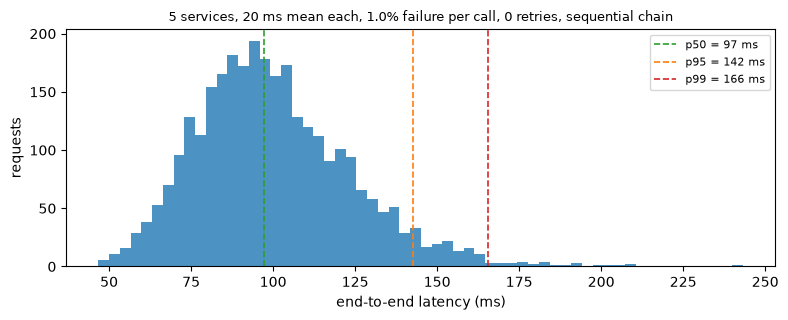

In [3]:
from dplab import latency_lab

latency_lab()

## 3. Resilience: timeout, retry, circuit breaker

Three small tools handle most of the damage. A **timeout** bounds how long you wait. A **retry** (with a limit, and only for idempotent calls) turns transient failures into success.
A **circuit breaker** notices that a dependency keeps failing, stops calling it for a cooling period so it can recover and so your own threads are not tied up, then probes.

In [4]:
class CircuitBreaker:
    def __init__(self, failures_to_open=3, cooldown_calls=5):
        self.failures, self.state, self.cooldown = 0, "closed", 0
        self.failures_to_open, self.cooldown_calls = failures_to_open, cooldown_calls
        self.log = []

    def call(self, fn, *args):
        if self.state == "open":
            self.cooldown -= 1
            if self.cooldown > 0:
                self.log.append("open: failing fast"); raise ConnectionError("circuit open")
            self.state = "half-open"; self.log.append("half-open: probing")
        try:
            result = fn(*args)
        except ConnectionError:
            self.failures += 1
            if self.state == "half-open" or self.failures >= self.failures_to_open:
                self.state, self.cooldown = "open", self.cooldown_calls
                self.log.append(f"opened after {self.failures} failures")
            raise
        self.failures, self.state = 0, "closed"
        return result

def with_retry(fn, attempts, *args):
    for i in range(attempts):
        try:
            return fn(*args)
        except ConnectionError as e:
            last = e
    raise last

# A dependency that is down for a while, then recovers.
calls = {"n": 0}
def flaky_dependency():
    calls["n"] += 1
    if 3 <= calls["n"] <= 12:
        raise ConnectionError("down")
    return "ok"

breaker = CircuitBreaker()
outcomes = []
for i in range(20):
    try:
        outcomes.append(breaker.call(flaky_dependency))
    except ConnectionError:
        outcomes.append("x")
print("outcomes:", " ".join(outcomes))
print("dependency was actually called", calls["n"], "times out of 20 attempts (the breaker absorbed the rest)")
print("\n".join(breaker.log))

outcomes: ok ok x x x x x x x x x x x x x x x x x x
dependency was actually called 8 times out of 20 attempts (the breaker absorbed the rest)
opened after 3 failures
open: failing fast
open: failing fast
open: failing fast
open: failing fast
half-open: probing
opened after 4 failures
open: failing fast
open: failing fast
open: failing fast
open: failing fast
half-open: probing
opened after 5 failures
open: failing fast
open: failing fast
open: failing fast
open: failing fast
half-open: probing
opened after 6 failures


> **What to notice.** While the circuit is open the dependency is not called at all: failing fast protects both sides. Retries and breakers only help with
> *transient* failures; a service that is simply wrong needs a rollback, not a retry.

## 4. The distributed monolith

Split a monolith along the wrong lines and you get services that must be deployed together, share a database, and call each other synchronously for every request.
You have paid for the network (latency, partial failure, operational complexity) and received none of the independence.

Signs: a change to one service needs a coordinated release of three others; two services write the same table; a request fans out to ten services in sequence.
The fix is usually to merge services back until the boundaries match the data ownership, then split again along those lines.

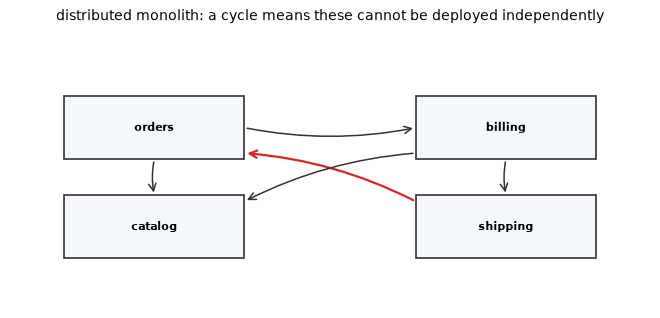

In [5]:
# A dependency graph with a cycle between services is the clearest symptom.
services = ["orders", "billing", "shipping", "catalog"]
edges = [("orders", "billing"), ("billing", "shipping"), ("shipping", "orders"), ("orders", "catalog"), ("billing", "catalog")]
component_diagram(services, edges, bad_edges={("shipping", "orders")}, layout={"orders": (0, 0), "billing": (1.5, 0), "shipping": (1.5, 1), "catalog": (0, 1)},
                  title="distributed monolith: a cycle means these cannot be deployed independently")

## Try it yourself

**Exercise 1.** Wrap the `OrderService.place` calls in `with_retry` with 3 attempts and measure, over 2000 orders, how the success rate changes with `fail_rate = 0.05`.

**Exercise 2.** Add a timeout to `Network.call`: if the drawn latency exceeds `timeout_ms`, raise `ConnectionError` instead of waiting.

**Exercise 3.** Make `BillingService.charge` idempotent with an `order_id` key, so that a retried charge does not bill twice. Why is this essential with retries?

**Exercise 4 (challenge).** Extend the circuit breaker with a time-based cooldown using `time.monotonic()` instead of a call count.

<details><summary>Solutions</summary>

```python
# Exercise 1
def place_with_retry(customer, item):
    return with_retry(orders.place, 3, customer, item)
net.fail_rate = 0.05
ok = 0
for _ in range(2000):
    try:
        place_with_retry("ada", "lamp"); ok += 1
    except ConnectionError:
        pass
print(f"success with 3 attempts: {ok / 2000:.1%}   (single attempt: about {0.95 ** 2:.1%})")

# Exercise 2: in Network.call, after drawing latency: if latency > self.timeout_ms: raise ConnectionError("timeout")

# Exercise 3
class BillingService:
    def __init__(self): self.db = {}
    def charge(self, order_id, customer, amount):
        if order_id in self.db: return "already charged"
        self.db[order_id] = (customer, amount); return "ok"
# Retrying a non-idempotent charge after a lost response would double-bill the customer.
```

</details>

## Checkpoint quiz

Four quick questions. Answer them before reading the takeaways. If you miss one, the explanation points you to the section to re-read.

In [6]:
from dplab import quiz

quiz('arch3')

Checkpoint quiz, Architecture 3 (static preview). Run this cell in JupyterLab to answer interactively.

Q1. Each microservice should
    a) share one database with the others
    b) own its data and be deployable independently
    c) be written in the same language
    d) be as small as a function

Q2. A request that passes through 5 services that are each 99 percent available succeeds about
    a) 99 percent of the time
    b) 95 percent of the time
    c) 90 percent of the time
    d) always

Q3. A 'distributed monolith' is
    a) a monolith on many machines
    b) services so coupled that they must be deployed together
    c) a modular monolith
    d) a service mesh

Q4. A circuit breaker
    a) retries forever
    b) stops calling a failing dependency for a while so failures do not cascade
    c) encrypts traffic
    d) balances load


## Key takeaways

* A microservice owns its data and deploys alone; that independence is the benefit and everything else is the price.
* Availability multiplies along a chain and tail latency adds up; keep chains short, fan out in parallel where you can.
* Timeouts, bounded retries on idempotent calls, and circuit breakers are the minimum kit.
* A distributed monolith has the costs without the benefits; boundaries must follow data ownership.

**Next:** taking the synchronous calls out. [Architecture 4](04_Event_Driven_and_CQRS.ipynb).

[Previous: Architecture 2: Layered, Hexagonal and MVC](02_Layered_Hexagonal_and_MVC.ipynb)  |  [Course Index](../00_Start_Here.ipynb)  |  [Next: Architecture 4: Event-Driven and CQRS](04_Event_Driven_and_CQRS.ipynb)